In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [33]:
data = pd.read_excel('predict_energy_consumption.xlsx')
print(data.head())

   temperature   humidity  wind_speed  solar_irradiance  energy_consumption
0    24.363503  31.107976    5.234114        705.432695          307.398145
1    38.767858  52.514057    4.939576        817.013258          412.444548
2    33.299849  72.376750   18.125092        325.421109          392.072418
3    29.966462  63.933493    4.990924        662.386690          119.254957
4    18.900466  68.393669    5.438995        614.571385          117.162261


In [34]:
X = data[['temperature', 'humidity', 'wind_speed', 'solar_irradiance']].values
y = data['energy_consumption'].values


In [35]:
X_train,X_test, y_train , y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
model = Sequential({
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), #input layer
    Dense(32,activation='relu'), #hidden layer
    Dense(1)#output layer 1 is no of neurons
})

C:\Users\sushm\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # optimizer to achive globel minima from local minma 

In [39]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose= 1) # to make the loss less

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 88718.3438 - mae: 269.2935 - val_loss: 83505.4297 - val_mae: 258.6386
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 89519.0547 - mae: 268.6025 - val_loss: 82761.4688 - val_mae: 257.1781
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 89698.3047 - mae: 268.9313 - val_loss: 81502.1719 - val_mae: 254.6833
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 89576.3047 - mae: 269.6453 - val_loss: 79478.0000 - val_mae: 250.6177
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 81547.9531 - mae: 254.7108 - val_loss: 76489.6484 - val_mae: 244.4948
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 78588.0469 - mae: 248.4225 - val_loss: 72297.7656 - val_mae: 235.6144
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 75751.3594 - mae: 244.1031 - val_loss: 66828.4453 - val_mae: 223.4524
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 69756.0859 - mae: 231.0533 - val_loss: 60312.

In [40]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Mean Absolute Error: {test_mae:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18261.0918 - mae: 115.9960 
Test Mean Absolute Error: 116.36


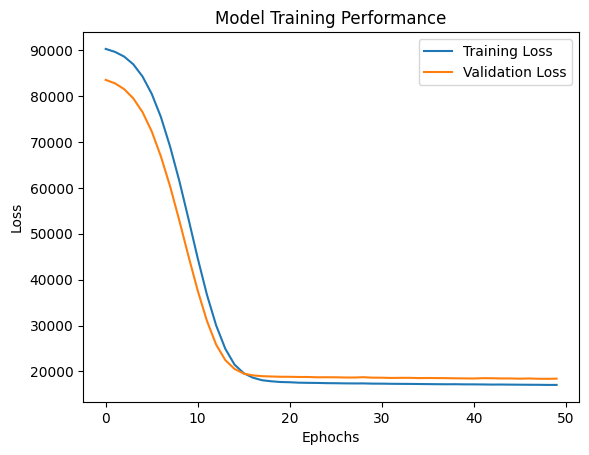

In [43]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Ephochs')
plt.ylabel('Loss')
plt.title('Model Training Performance')
plt.legend()
plt.show()

In [44]:
predictions = model.predict(X_test)
predictions

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([[283.9398 ],
       [251.82913],
       [267.04688],
       [201.87271],
       [356.6013 ],
       [314.64453],
       [334.428  ],
       [296.13675],
       [297.8039 ],
       [284.7849 ],
       [235.89955],
       [266.1757 ],
       [278.79013],
       [237.09552],
       [310.24457],
       [322.62198],
       [257.32178],
       [316.00247],
       [302.24826],
       [240.7362 ],
       [273.3635 ],
       [286.68536],
       [292.21222],
       [282.57602],
       [243.95886],
       [238.80113],
       [262.67578],
       [310.104  ],
       [321.94244],
       [266.31934],
       [227.2867 ],
       [305.81946],
       [298.1607 ],
       [279.36115],
       [314.39322],
       [285.52863],
       [209.75005],
       [254.7815 ],
       [283.6023 ],
       [241.4964 ],
       [253.05083],
       [247.62585],
       [259.98175],
       [248.76503],
       [268.49927],
       [250.41414],
       [275.21222],
       [251.42432],
       [297.6949 ],
       [304.5547 ],


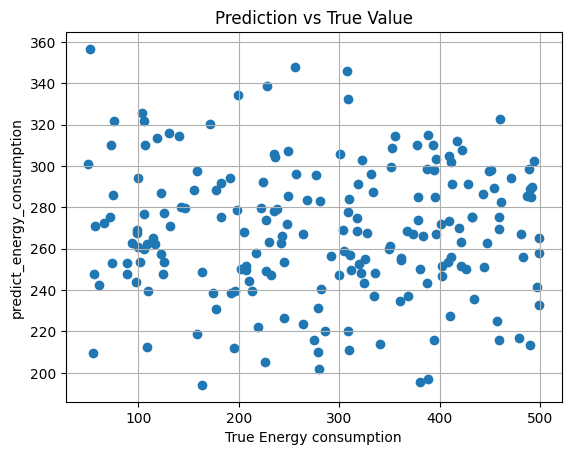

In [46]:
plt.scatter(y_test, predictions)
plt.ylabel("predict_energy_consumption")
plt.xlabel("True Energy consumption")
plt.title('Prediction vs True Value')
plt.grid()
plt.show()